In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, max_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### LEITURA DOS DATASETS

In [23]:
df_avaliado = pd.read_csv('datasets/avaliacao_modelos_congestionamento_regressãolinear.csv')
df_treino = pd.read_csv('datasets/df_treino_congestionamento_regressãolinear.csv')
df_futuro_12 = pd.read_csv('results/previsoes_futuras_congestionamento_12_meses.csv')
df_futuro_3 = pd.read_csv('results/previsoes_futuras_congestionamento_3_meses.csv')
df_futuro_6 = pd.read_csv('results/previsoes_futuras_congestionamento_6_meses.csv')
#!/usr/bin/env python3

### AMOSTRA DO TREINO

In [24]:
df_treino.sample(5)

,comarca,serventia,mes_ref,Taxa de Congestionamento_mes (%),mes_ordinal
15926,SANTO ANTÔNIO DO DESCOBERTO,"1ª Vara (Cível, de Família, Sucessões e da Inf...",2022-10-31,81.021667,738459
7796,GOIÂNIA,2º Juizado de Violência Doméstica e Familiar c...,2022-09-30,50.538333,738428
16506,SÃO DOMINGOS,Vara Judicial,2025-02-28,89.536000,739310
2065,APARECIDA DE GOIÂNIA,4ª Vara Cível,2024-10-31,96.627941,739190
17811,TRIBUNAL DE JUSTIÇA,GABINETE DES. IVO FAVARO,2024-06-30,11.132500,739067


### AVALIAÇÃO GLOBAL DO MODELO

In [25]:
# Vamos calcular o erro do nosso modelo nos dados de teste (validação)

mae = mean_absolute_error(df_avaliado['Taxa de Congestionamento_mes (%)'], df_avaliado['Taxa_Prevista'])
rmse = np.sqrt(mean_squared_error(df_avaliado['Taxa de Congestionamento_mes (%)'], df_avaliado['Taxa_Prevista']))

print("=== Performance Global do Modelo (Baseline: Regressão Linear) ===")
print(f"Erro Absoluto Médio (MAE): {mae:.2f} p.p.")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f} p.p.")

# Análise de Erro: Onde o modelo errou mais?
df_avaliado['Erro_Absoluto'] = abs(df_avaliado['Taxa de Congestionamento_mes (%)'] - df_avaliado['Taxa_Prevista'])
top_erros = df_avaliado.sort_values(by='Erro_Absoluto', ascending=False).head(5)

print("\n=== Top 5 Maiores Erros de Previsão ===")
display(top_erros[['comarca', 'serventia', 'mes_ref', 'Taxa de Congestionamento_mes (%)', 'Taxa_Prevista', 'Erro_Absoluto']])

=== Performance Global do Modelo (Baseline: Regressão Linear) ===
Erro Absoluto Médio (MAE): 11.86 p.p.
Raiz do Erro Quadrático Médio (RMSE): 22.23 p.p.

=== Top 5 Maiores Erros de Previsão ===


,comarca,serventia,mes_ref,Taxa de Congestionamento_mes (%),Taxa_Prevista,Erro_Absoluto
1221,TRIBUNAL DE JUSTIÇA,GABINETE DES. ALEXANDRE BIZZOTTO,2025-10-31,100.0,4.620730,95.379270
1428,TRIBUNAL DE JUSTIÇA,GABINETE DESA. ROZANA FERNANDES CAMAPUM,2025-10-31,100.0,5.287338,94.712662
1377,TRIBUNAL DE JUSTIÇA,GABINETE DES. WILSON DA SILVA DIAS,2025-10-31,100.0,5.557516,94.442484
1212,TRIBUNAL DE JUSTIÇA,GABINETE DE JUIZ SUBSTITUTO EM 2º GRAU DR. ROG...,2025-10-31,100.0,5.669206,94.330794
1314,TRIBUNAL DE JUSTIÇA,GABINETE DES. JOSÉ PAGANUCCI JÚNIOR,2025-10-31,100.0,6.712565,93.287435


### VISUALIZAÇÕES

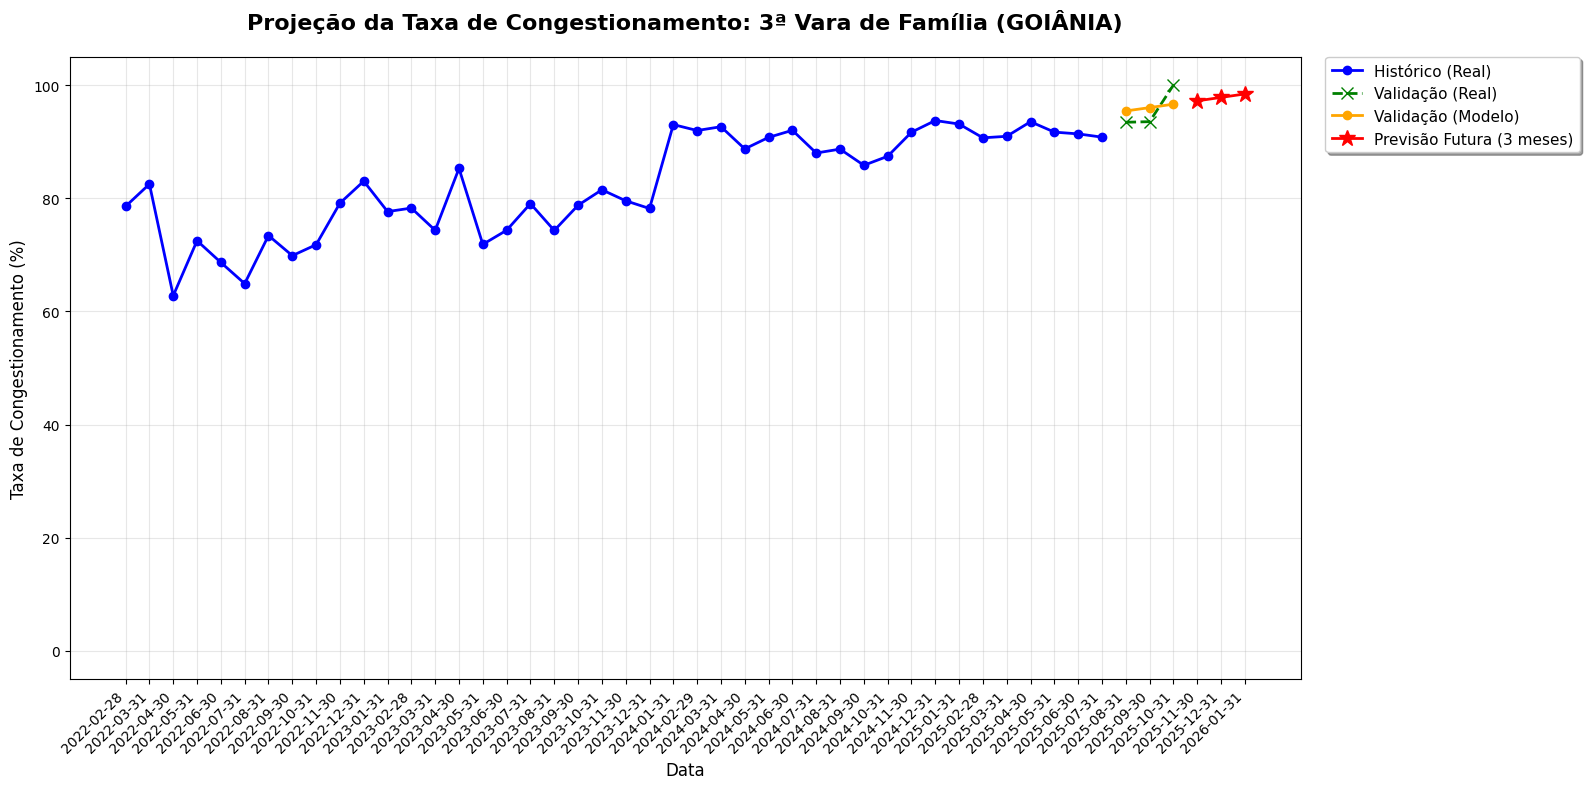

In [26]:
# Escolher uma serventia aleatória para plotar: Passado, Validação e Futuro

# Selecionar uma serventia que tenha dados suficientes
amostra = '3ª Vara de Família'
comarca_amostra = 'GOIÂNIA'

# Filtrar dados
hist = df_treino[(df_treino['serventia'] == amostra) & (df_treino['comarca'] == comarca_amostra)]
val = df_avaliado[(df_avaliado['serventia'] == amostra) & (df_avaliado['comarca'] == comarca_amostra)]
fut = df_futuro_3[(df_futuro_3['serventia'] == amostra) & (df_futuro_3['comarca'] == comarca_amostra)]

plt.figure(figsize=(16, 8))

# Plotar Histórico (Treino)
plt.plot(hist['mes_ref'], hist['Taxa de Congestionamento_mes (%)'], 
         label='Histórico (Real)', marker='o', color='blue', linewidth=2, markersize=6)

# Plotar Validação (Real vs Previsto)
plt.plot(val['mes_ref'], val['Taxa de Congestionamento_mes (%)'], 
         label='Validação (Real)', marker='x', color='green', 
         linestyle='--', linewidth=2, markersize=8)
plt.plot(val['mes_ref'], val['Taxa_Prevista'], 
         label='Validação (Modelo)', marker='o', color='orange', 
         linewidth=2, markersize=6)

# Plotar Futuro
plt.plot(fut['data_futura'], fut['taxa_prevista'], 
         label='Previsão Futura (3 meses)', marker='*', color='red', 
         markersize=12, linewidth=2)

plt.title(f'Projeção da Taxa de Congestionamento: {amostra} ({comarca_amostra})', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Taxa de Congestionamento (%)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotaciona 45 graus e alinha à direita

# MELHORIAS NA LEGENDA:
# Opção 1: Legenda fora do gráfico (recomendado para evitar sobreposição)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,
           fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.ylim(-5, 105)  # Margem para visualização
plt.grid(True, alpha=0.3)
plt.tight_layout()  # Ajusta automaticamente os espaçamentos
plt.show()

In [27]:
df_futuro_3[(df_futuro_3['comarca'] == 'GOIÂNIA') & (df_futuro_3['serventia'] == '3ª Vara de Família')]

,comarca,serventia,data_futura,horizonte_meses,taxa_prevista,mes_no_horizonte
597,GOIÂNIA,3ª Vara de Família,2025-11-30,3,97.21,1
598,GOIÂNIA,3ª Vara de Família,2025-12-31,3,97.82,2
599,GOIÂNIA,3ª Vara de Família,2026-01-31,3,98.43,3


In [28]:
df_treino[(df_treino['serventia'] == '3ª Vara de Família') & (df_treino['comarca'] == 'GOIÂNIA')]

,comarca,serventia,mes_ref,Taxa de Congestionamento_mes (%),mes_ordinal
8226,GOIÂNIA,3ª Vara de Família,2022-02-28,78.570000,738214
8227,GOIÂNIA,3ª Vara de Família,2022-03-31,82.500000,738245
8228,GOIÂNIA,3ª Vara de Família,2022-04-30,62.782500,738275
8229,GOIÂNIA,3ª Vara de Família,2022-05-31,72.494000,738306
8230,GOIÂNIA,3ª Vara de Família,2022-06-30,68.646667,738336
8231,GOIÂNIA,3ª Vara de Família,2022-07-31,64.907143,738367
8232,GOIÂNIA,3ª Vara de Família,2022-08-31,73.408571,738398
8233,GOIÂNIA,3ª Vara de Família,2022-09-30,69.853333,738428
8234,GOIÂNIA,3ª Vara de Família,2022-10-31,71.786000,738459
8235,GOIÂNIA,3ª Vara de Família,2022-11-30,79.133000,738489
